# Ornstein-Uhlenbeck Generator

The Ornstein-Uhlenbeck process is a mean-reverting stochastic process commonly used to model interest rates, commodity prices, and other financial variables that exhibit mean reversion.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import OrnsteinUhlenbeckGenerator

## 1. Basic Mean-Reverting Process

Start at 80 and revert towards a long-term mean of 100.

In [ ]:
basic_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "theta": 0.5,
    "mu": 100.0,
    "sigma": 5.0,
    "initial_value": 80.0,
    "seed": 42,
}

basic_gen = OrnsteinUhlenbeckGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} observations (mean-reverting to {basic_params['mu']})")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Std={basic_df['y'].std():.4f}")
basic_df.head(10)

Generated 200 observations (mean-reverting to 100.0)
Statistics: Mean=99.6442, Std=6.3555


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,80.0
"""0""",2000-01-02 00:00:00,82.992031
"""0""",2000-01-03 00:00:00,86.966288
"""0""",2000-01-04 00:00:00,98.258423
"""0""",2000-01-05 00:00:00,100.832489
"""0""",2000-01-06 00:00:00,97.918522
"""0""",2000-01-07 00:00:00,95.635111
"""0""",2000-01-08 00:00:00,100.825374
"""0""",2000-01-09 00:00:00,98.708297


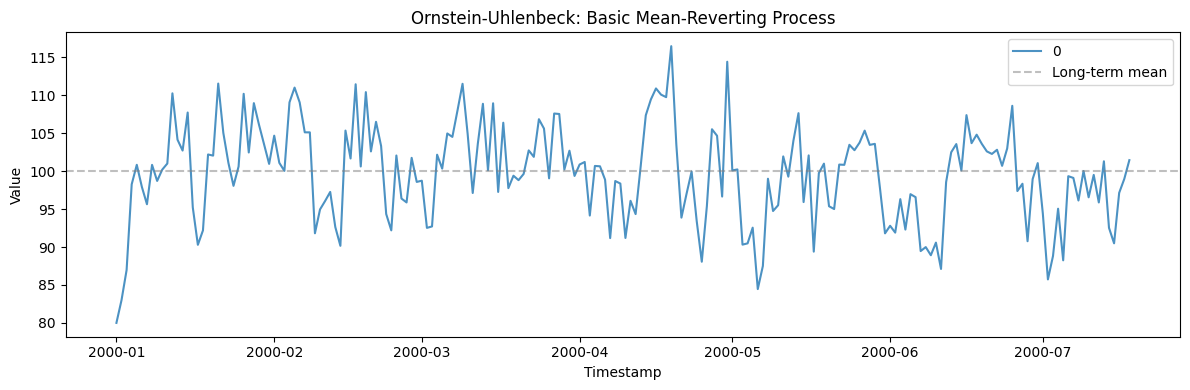

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=100.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: Basic Mean-Reverting Process")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Fast Mean Reversion (High Theta)

A high theta value causes the process to revert to the mean quickly, even when starting far away.

In [ ]:
fast_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "theta": 1.5,
    "mu": 50.0,
    "sigma": 3.0,
    "initial_value": 100.0,
    "seed": 42,
}

fast_gen = OrnsteinUhlenbeckGenerator(engine="polars", **fast_params)
fast_df = fast_gen.generate(n_series=1)

print(f"Generated {len(fast_df)} observations with fast mean reversion")
print(f"Statistics: Mean={fast_df['y'].mean():.4f}, Std={fast_df['y'].std():.4f}")
fast_df.head(10)

Generated 200 observations with fast mean reversion
Statistics: Mean=50.1392, Std=5.6323


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,20.795219
"""0""",2000-01-03 00:00:00,61.884554
"""0""",2000-01-04 00:00:00,46.92289
"""0""",2000-01-05 00:00:00,52.560521
"""0""",2000-01-06 00:00:00,47.221106
"""0""",2000-01-07 00:00:00,49.394957
"""0""",2000-01-08 00:00:00,52.107212
"""0""",2000-01-09 00:00:00,47.92376


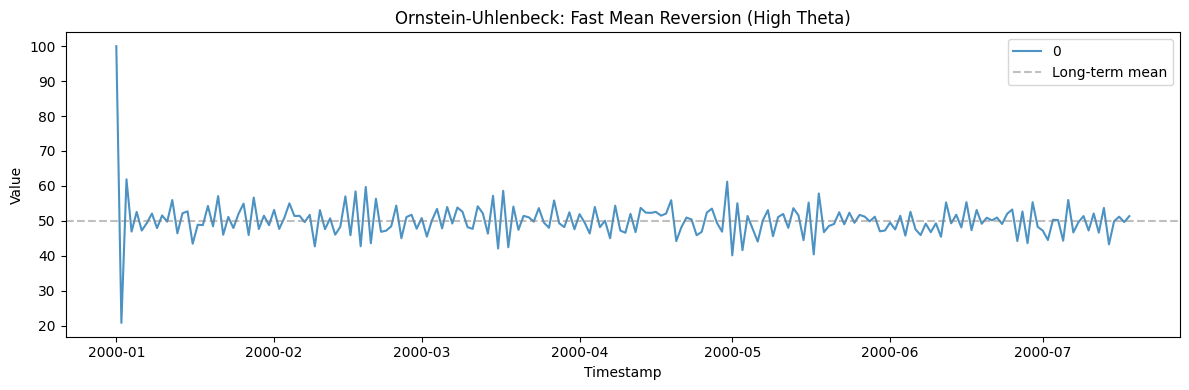

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in fast_df["unique_id"].unique().to_list():
    series = fast_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=50.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: Fast Mean Reversion (High Theta)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Slow Mean Reversion (Low Theta)

A low theta means the process reverts slowly, behaving more like a random walk in the short term.

In [ ]:
slow_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "theta": 0.1,
    "mu": 100.0,
    "sigma": 5.0,
    "initial_value": 80.0,
    "seed": 42,
}

slow_gen = OrnsteinUhlenbeckGenerator(engine="polars", **slow_params)
slow_df = slow_gen.generate(n_series=1)

print(f"Generated {len(slow_df)} observations with slow mean reversion")
print(f"Statistics: Mean={slow_df['y'].mean():.4f}, Std={slow_df['y'].std():.4f}")
slow_df.head(10)

Generated 200 observations with slow mean reversion
Statistics: Mean=98.8006, Std=12.5962


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,80.0
"""0""",2000-01-02 00:00:00,74.992031
"""0""",2000-01-03 00:00:00,72.9631
"""0""",2000-01-04 00:00:00,80.442069
"""0""",2000-01-05 00:00:00,84.10114
"""0""",2000-01-06 00:00:00,83.193303
"""0""",2000-01-07 00:00:00,81.549823
"""0""",2000-01-08 00:00:00,86.402659
"""0""",2000-01-09 00:00:00,86.058004


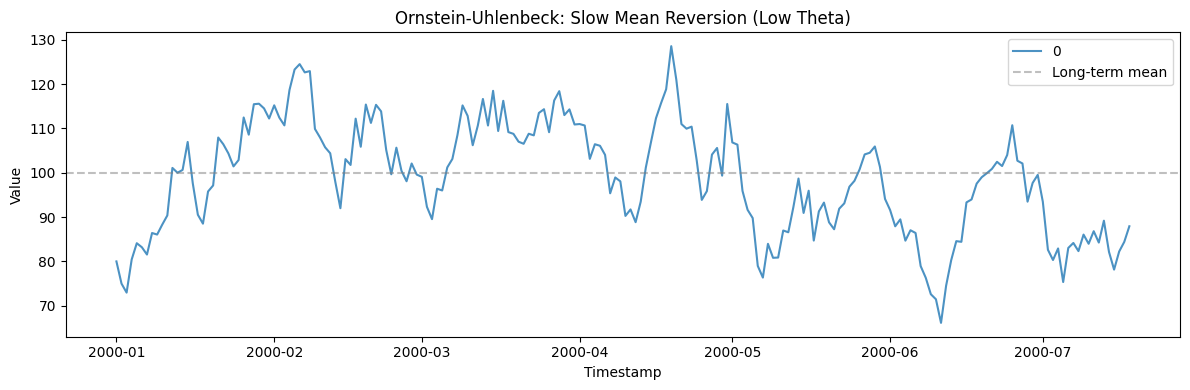

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in slow_df["unique_id"].unique().to_list():
    series = slow_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=100.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: Slow Mean Reversion (Low Theta)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. High Volatility Mean Reversion

Higher sigma produces larger fluctuations around the long-term mean.

In [ ]:
high_vol_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "theta": 0.5,
    "mu": 100.0,
    "sigma": 15.0,
    "initial_value": 100.0,
    "seed": 42,
}

high_vol_gen = OrnsteinUhlenbeckGenerator(engine="polars", **high_vol_params)
high_vol_df = high_vol_gen.generate(n_series=1)

print(f"Generated {len(high_vol_df)} observations with high volatility")
print(f"Statistics: Mean={high_vol_df['y'].mean():.4f}, Std={high_vol_df['y'].std():.4f}")
high_vol_df.head(10)

Generated 200 observations with high volatility
Statistics: Mean=99.5327, Std=18.1821


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,78.976093
"""0""",2000-01-03 00:00:00,75.898864
"""0""",2000-01-04 00:00:00,102.275269
"""0""",2000-01-05 00:00:00,106.247467
"""0""",2000-01-06 00:00:00,95.630566
"""0""",2000-01-07 00:00:00,87.842834
"""0""",2000-01-08 00:00:00,102.944872
"""0""",2000-01-09 00:00:00,96.359266


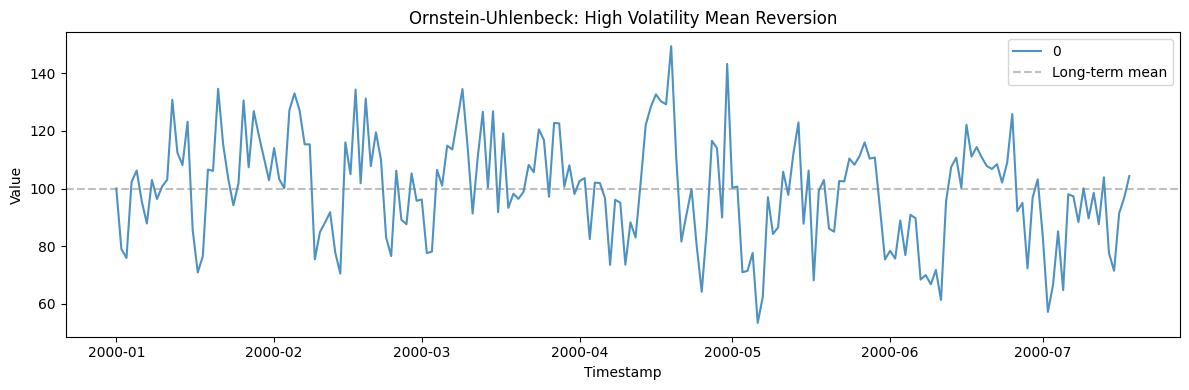

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_vol_df["unique_id"].unique().to_list():
    series = high_vol_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=100.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: High Volatility Mean Reversion")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Multiple Mean-Reverting Series

Generate multiple independent OU processes in one call.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "theta": 0.5,
    "mu": 100.0,
    "sigma": 5.0,
    "initial_value": 80.0,
    "seed": 42,
}

multi_gen = OrnsteinUhlenbeckGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=99.8925, Std=5.8501


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,80.0
"""0""",2000-01-02 00:00:00,82.992031
"""0""",2000-01-03 00:00:00,86.966288
"""0""",2000-01-04 00:00:00,98.258423
"""0""",2000-01-05 00:00:00,100.832489
"""0""",2000-01-06 00:00:00,97.918522
"""0""",2000-01-07 00:00:00,95.635111
"""0""",2000-01-08 00:00:00,100.825374
"""0""",2000-01-09 00:00:00,98.708297


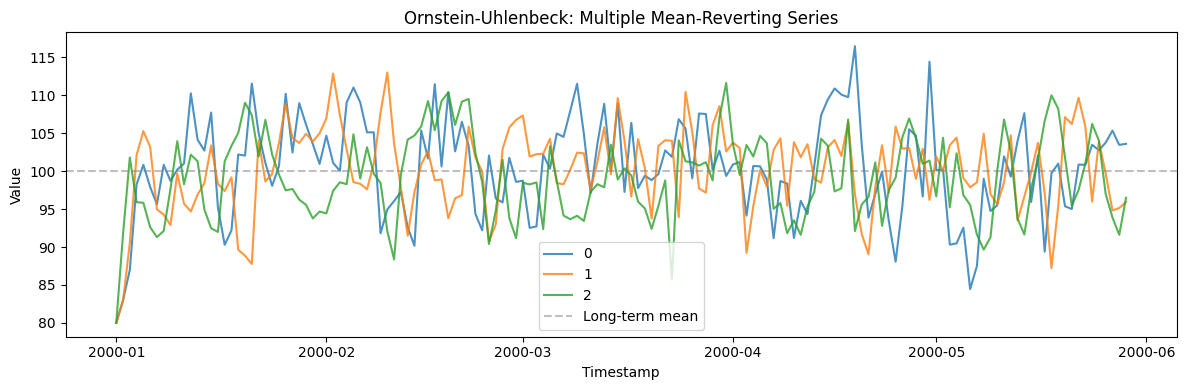

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.axhline(y=100.0, color="gray", linestyle="--", alpha=0.5, label="Long-term mean")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Ornstein-Uhlenbeck: Multiple Mean-Reverting Series")
ax.legend()
plt.tight_layout()
plt.show()